# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:**  Varun S G <br>
**`Roll Number`:**  U20230015 <br>
**`GitHub Branch`:** varun_U20230015  

# Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

from rlcmab_sampler import sampler


# Load Datasets

In [ ]:
# Quick peek at the raw data
_news = pd.read_csv("data/news_articles.csv")
_train = pd.read_csv("data/train_users.csv")

print("=== News Articles (first 3 rows) ===")
display(_news.head(3))

print("\n=== Train Users (first 3 rows) ===")
display(_train.head(3))

=== News Articles (first 3 rows) ===


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23



=== Train Users (first 3 rows) ===


,user_id,age,income,clicks,purchase_amount,label
0,1,28,58242,81,378.38,user3
1,2,28,38225,21,114.50,user3
2,3,39,95017,41,66.24,user2


## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [ ]:
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print("Raw shapes:")
print(f"  news_articles : {news_df.shape}")
print(f"  train_users   : {train_users.shape}")
print(f"  test_users    : {test_users.shape}")

print("\nMissing values in news_articles:")
print(news_df.isnull().sum())

# Drop rows with missing headlines
news_df = news_df.dropna(subset=["headline"])

# Fill missing short_description and authors with empty strings
news_df["short_description"] = news_df["short_description"].fillna("")
news_df["authors"] = news_df["authors"].fillna("")

print(f"\nNews articles after cleaning: {news_df.shape}")

# Filter news to the 4 bandit categories 
bandit_categories = ["ENTERTAINMENT", "EDUCATION", "TECH", "CRIME"]
news_filtered = news_df[news_df["category"].isin(bandit_categories)].copy()
news_filtered.reset_index(drop=True, inplace=True)

print(f"\nFiltered news articles (4 categories): {news_filtered.shape}")
print(news_filtered["category"].value_counts())

# Verify user datasets have no missing values
print("\nMissing values in train_users:")
print(train_users.isnull().sum())
print("\nMissing values in test_users:")
print(test_users.isnull().sum())

# Encode user labels
label_mapping = {"user1": "User1", "user2": "User2", "user3": "User3"}
train_users["label"] = train_users["label"].map(label_mapping)
test_users["label"] = test_users["label"].map(label_mapping)

# Encode labels numerically for the classifier
user_label_encoder = LabelEncoder()
user_label_encoder.fit(["User1", "User2", "User3"])

train_users["label_encoded"] = user_label_encoder.transform(train_users["label"])
test_users["label_encoded"] = user_label_encoder.transform(test_users["label"])

print("\nLabel encoding:")
for cls, code in zip(user_label_encoder.classes_, user_label_encoder.transform(user_label_encoder.classes_)):
    print(f"  {cls} -> {code}")

feature_cols = ["age", "income", "clicks", "purchase_amount"]

print("\nPreprocessed train_users sample:")
train_users.head()

Raw shapes:
  news_articles : (209527, 6)
  train_users   : (2000, 6)
  test_users    : (2000, 6)

Missing values in news_articles:
link                     0
headline                 6
category                 0
short_description    19712
authors              37418
date                     0
dtype: int64

News articles after cleaning: (209521, 6)

Filtered news articles (4 categories): (24042, 6)
category
ENTERTAINMENT    17362
CRIME             3562
TECH              2104
EDUCATION         1014
Name: count, dtype: int64

Missing values in train_users:
user_id            0
age                0
income             0
clicks             0
purchase_amount    0
label              0
dtype: int64

Missing values in test_users:
user_id            0
age                0
income             0
clicks             0
purchase_amount    0
label              0
dtype: int64

Label encoding:
  User1 -> 0
  User2 -> 1
  User3 -> 2

Preprocessed train_users sample:


,user_id,age,income,clicks,purchase_amount,label,label_encoded
0,1,28,58242,81,378.38,User3,2
1,2,28,38225,21,114.50,User3,2
2,3,39,95017,41,66.24,User2,1
3,4,52,33473,98,496.88,User3,2
4,5,29,80690,5,293.24,User1,0


## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


User Classification Accuracy (test set): 0.3290

Classification Report:
              precision    recall  f1-score   support

       User1       0.35      0.50      0.41       672
       User2       0.32      0.36      0.34       679
       User3       0.29      0.12      0.17       649

    accuracy                           0.33      2000
   macro avg       0.32      0.33      0.31      2000
weighted avg       0.32      0.33      0.31      2000

Confusion Matrix:
[[335 255  82]
 [316 242 121]
 [316 252  81]]


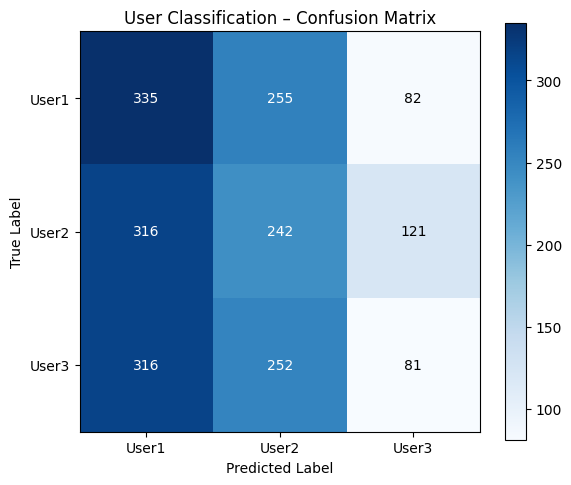

<Figure size 640x480 with 0 Axes>

In [4]:
# Prepare features and labels
X_train = train_users[feature_cols].values
y_train = train_users["label_encoded"].values

X_test = test_users[feature_cols].values
y_test = test_users["label_encoded"].values

# Logistic Regression classifier
clf = LogisticRegression(max_iter=10000, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"User Classification Accuracy (test set): {test_accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=user_label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(cm.shape[1]),
    yticks=np.arange(cm.shape[0]),
    xticklabels=user_label_encoder.classes_,
    yticklabels=user_label_encoder.classes_,
    ylabel="True Label",
    xlabel="Predicted Label",
    title="User Classification – Confusion Matrix",
)
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()


plt.tight_layout()
plt.show()


# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach
